# 02 — Random Forest Training, Testing and Evaluation

This notebook loads the prepared train/test files, builds a leakage-safe preprocessing pipeline, trains a Random Forest Regression model, and evaluates its ability to predict historical ride cost or expected base revenue.

**Outputs written to `artifacts/`:**

- `random_forest_revenue_model.joblib`
- `model_metrics.csv`
- `train_environment_costs.csv`
- `test_environment_costs.csv`

Run notebook 01 first.

## 1. Imports and prepared data

In [1]:
from pathlib import Path
import json
import random
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
plt.style.use('ggplot')
pd.set_option('display.max_columns', None)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'dynamic_pricing.csv').exists() and (PROJECT_ROOT.parent / 'dynamic_pricing.csv').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
ARTIFACT_DIR = PROJECT_ROOT / 'artifacts'
ARTIFACT_DIR.mkdir(exist_ok=True)
print(f'Project root: {PROJECT_ROOT.resolve()}')

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

Project root: C:\Users\spinn\OneDrive\Documents\NCI AI Masters\Artificial Intellegence Driven Decision Making\CA2 Project


In [2]:
required = [
    'train_features.csv', 'test_features.csv',
    'train_target.csv', 'test_target.csv'
]
missing = [name for name in required if not (ARTIFACT_DIR / name).exists()]
if missing:
    raise FileNotFoundError(f'Run notebook 01 first. Missing: {missing}')

X_train = pd.read_csv(ARTIFACT_DIR / 'train_features.csv')
X_test = pd.read_csv(ARTIFACT_DIR / 'test_features.csv')
y_train = pd.read_csv(ARTIFACT_DIR / 'train_target.csv').iloc[:, 0]
y_test = pd.read_csv(ARTIFACT_DIR / 'test_target.csv').iloc[:, 0]

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
display(X_train.head())

X_train: (800, 12) | X_test: (200, 12)


,number_of_riders,number_of_drivers,demand_supply_ratio,riders_per_minute,expected_ride_duration,number_of_past_rides,average_ratings,experienced_customer,location_category,customer_loyalty_status,time_of_booking,vehicle_type
0,57,38,1.500000,0.435115,131,54,4.10,1,Suburban,Silver,Night,Premium
1,21,8,2.625000,0.250000,84,57,4.78,1,Urban,Regular,Night,Premium
2,63,48,1.312500,0.900000,70,88,4.09,1,Rural,Regular,Morning,Economy
3,35,23,1.521739,0.213415,164,58,3.78,1,Suburban,Gold,Afternoon,Economy
4,83,64,1.296875,0.761468,109,78,4.01,1,Suburban,Gold,Evening,Economy


## 2. Preprocessing pipeline

Numerical features use median imputation and standardization. Categorical fields—location, loyalty, booking time, and vehicle type—use most-frequent imputation and one-hot encoding. All preprocessing is fitted only on the training data.

Scaling is not required by Random Forests, but it keeps this preprocessing pipeline reusable for scale-sensitive models.

In [3]:
categorical_features = [
    'location_category', 'customer_loyalty_status',
    'time_of_booking', 'vehicle_type'
]
numeric_features = [
    column for column in X_train.columns
    if column not in categorical_features
]

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer([
    ('numeric', numeric_pipeline, numeric_features),
    ('categorical', categorical_pipeline, categorical_features)
])

print('Numerical features:', numeric_features)
print('Categorical features:', categorical_features)

Numerical features: ['number_of_riders', 'number_of_drivers', 'demand_supply_ratio', 'riders_per_minute', 'expected_ride_duration', 'number_of_past_rides', 'average_ratings', 'experienced_customer']
Categorical features: ['location_category', 'customer_loyalty_status', 'time_of_booking', 'vehicle_type']


## 3. Train the Random Forest

Random Forest is appropriate because it captures nonlinear interactions between demand, supply, duration, customer characteristics, and trip type. It is also robust on small mixed-feature tabular datasets and requires relatively little tuning.

In [4]:
revenue_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=2,
        random_state=SEED,
        n_jobs=-1
    ))
])

revenue_model.fit(X_train, y_train)
train_predictions = revenue_model.predict(X_train)
test_predictions = revenue_model.predict(X_test)
print('Random Forest training complete.')

Random Forest training complete.


## 4. Test-set evaluation

In [5]:
mae = mean_absolute_error(y_test, test_predictions)
rmse = np.sqrt(mean_squared_error(y_test, test_predictions))
r2 = r2_score(y_test, test_predictions)

metrics = pd.DataFrame({
    'metric': ['MAE', 'RMSE', 'R2'],
    'value': [mae, rmse, r2]
})
display(metrics.style.format({'value': '{:,.3f}'}))

prediction_check = pd.DataFrame({
    'actual_historical_cost': y_test,
    'predicted_historical_cost': test_predictions
})
prediction_check['absolute_error'] = (
    prediction_check['actual_historical_cost'] -
    prediction_check['predicted_historical_cost']
).abs()
display(prediction_check.head(10).round(2))

,metric,value
0,MAE,55.578
1,RMSE,74.427
2,R2,0.848


,actual_historical_cost,predicted_historical_cost,absolute_error
0,470.27,385.61,84.66
1,286.41,309.67,23.26
2,552.27,649.52,97.26
3,267.74,338.66,70.92
4,111.11,121.29,10.18
5,359.13,398.67,39.54
6,173.89,178.36,4.47
7,196.32,193.20,3.12
8,555.40,398.01,157.39
9,163.21,134.52,28.70


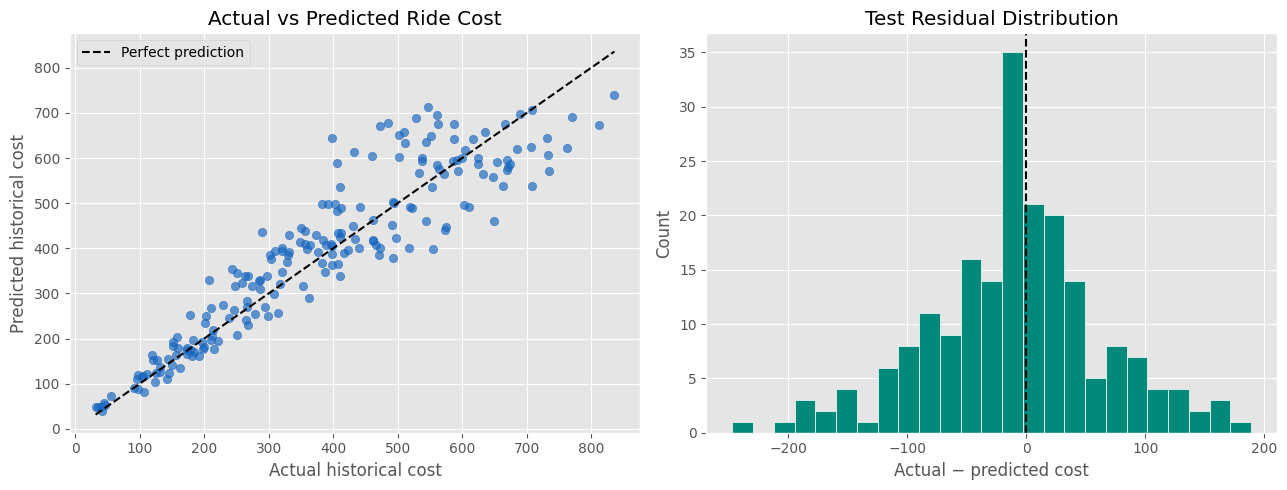

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_test, test_predictions, alpha=0.65, color='#1565C0')
limits = [min(y_test.min(), test_predictions.min()),
          max(y_test.max(), test_predictions.max())]
axes[0].plot(limits, limits, '--', color='black', label='Perfect prediction')
axes[0].set_title('Actual vs Predicted Ride Cost')
axes[0].set_xlabel('Actual historical cost')
axes[0].set_ylabel('Predicted historical cost')
axes[0].legend()

residuals = y_test.to_numpy() - test_predictions
axes[1].hist(residuals, bins=25, color='#00897B', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title('Test Residual Distribution')
axes[1].set_xlabel('Actual − predicted cost')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()

## 5. Save the simulated environment model

The RL agent must not read the target value directly. Instead, this fitted model estimates the historical/base cost from a market state. The pricing multiplier is applied to that estimate inside the simulated environment.

In [7]:
joblib.dump(revenue_model, ARTIFACT_DIR / 'random_forest_revenue_model.joblib')
metrics.to_csv(ARTIFACT_DIR / 'model_metrics.csv', index=False)
pd.DataFrame({'predicted_base_cost': train_predictions}).to_csv(
    ARTIFACT_DIR / 'train_environment_costs.csv', index=False
)
pd.DataFrame({
    'actual_historical_cost': y_test,
    'predicted_base_cost': test_predictions
}).to_csv(ARTIFACT_DIR / 'test_environment_costs.csv', index=False)

print(f'Saved model to: {ARTIFACT_DIR / "random_forest_revenue_model.joblib"}')
print(f'MAE={mae:.2f}, RMSE={rmse:.2f}, R²={r2:.3f}')

Saved model to: C:\Users\spinn\OneDrive\Documents\NCI AI Masters\Artificial Intellegence Driven Decision Making\CA2 Project\artifacts\random_forest_revenue_model.joblib
MAE=55.58, RMSE=74.43, R²=0.848


## Stage complete

The prediction model is trained and evaluated. Continue with **03_q_learning_training.ipynb**.